In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Sin GPU")


2.6.0+cu124
True
12.4
NVIDIA GeForce RTX 3060 Laptop GPU


In [2]:
import os
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Usando dispositivo:", DEVICE)


Usando dispositivo: cuda


### Carga del dataset de landmarks

Cada CSV contiene 126 coordenadas + etiqueta.
Se codifican las etiquetas con `LabelEncoder` y
se normalizan las características con `StandardScaler`.


In [3]:
data, labels = [], []
for file in glob.glob("MegaDataSet/*.csv"):
    label = os.path.basename(file).replace(".csv", "")
    df = pd.read_csv(file)
    for _, row in df.iterrows():
        data.append(row.values[:-1])
        labels.append(label)

X = np.array(data, dtype=np.float32)
y = np.array(labels)

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Total muestras: {len(X)} | Clases detectadas: {encoder.classes_}")


Total muestras: 20993 | Clases detectadas: ['abrirPuerta' 'anteriorMelodia' 'apagarLuces' 'encenderLuces'
 'modoNormal' 'modoSuper' 'siguienteMelodia']


### Arquitectura DGRNet (Deep Gesture Recognition Network)

Estructura jerárquica:
- Bloques densos con BatchNorm + ReLU + Dropout.  
- Residual connections entre capas profundas.  
- Capa final softmax con número de gestos.

El modelo está optimizado para aprendizaje estable y convergencia rápida.


In [4]:
class DGRBlock(nn.Module):
    def __init__(self, in_f, out_f, dropout=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(in_f, out_f),
            nn.BatchNorm1d(out_f),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.block(x)

class DGRNet(nn.Module):
    def __init__(self, num_features, num_classes):
        super().__init__()
        self.fc1 = DGRBlock(num_features, 512)
        self.fc2 = DGRBlock(512, 256)
        self.fc3 = DGRBlock(256, 128)
        self.fc4 = DGRBlock(128, 64)
        self.res_proj = nn.Linear(256, 128)  # Proyección residual compatible
        self.output = nn.Linear(64, num_classes)

    def forward(self, x):
        x1 = self.fc1(x)
        x2 = self.fc2(x1)
        x3 = self.fc3(x2)
        # proyección para ajustar dimensión antes de la suma residual
        x3 = x3 + self.res_proj(x2) * 0.5
        x4 = self.fc4(x3)
        return self.output(x4)

num_features = X_train.shape[1]
num_classes = len(encoder.classes_)

model = DGRNet(num_features, num_classes).to(DEVICE)
print("Modelo DGRNet configurado con:", num_features, "entradas y", num_classes, "clases.")


Modelo DGRNet configurado con: 125 entradas y 7 clases.


### Entrenamiento con PyTorch

Configuración:
- Optimizador AdamW (mejor estabilidad).  
- Scheduler de reducción de LR por paciencia.  
- Épocas: 50, Batch: 64.  
- Métricas: pérdida, precisión y validación.


In [5]:
print("Shape X_train:", X_train.shape)


Shape X_train: (16794, 125)


In [6]:
train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)
test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5)

train_loss, test_loss, train_acc, test_acc = [], [], [], []

for epoch in range(50):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        out = model(Xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, pred = torch.max(out, 1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for Xv, yv in test_loader:
            Xv, yv = Xv.to(DEVICE), yv.to(DEVICE)
            o = model(Xv)
            loss_v = criterion(o, yv)
            val_loss += loss_v.item()
            _, pv = torch.max(o, 1)
            val_correct += (pv == yv).sum().item()
            val_total += yv.size(0)

    train_loss.append(total_loss / len(train_loader))
    test_loss.append(val_loss / len(test_loader))
    train_acc.append(correct / total)
    test_acc.append(val_correct / val_total)
    scheduler.step(test_loss[-1])

    print(f"Época [{epoch+1}/50] | "
          f"Loss train: {train_loss[-1]:.4f} | "
          f"Loss val: {test_loss[-1]:.4f} | "
          f"Acc train: {train_acc[-1]*100:.2f}% | "
          f"Acc val: {test_acc[-1]*100:.2f}%")


Época [1/50] | Loss train: 0.1829 | Loss val: 0.0129 | Acc train: 98.07% | Acc val: 99.81%
Época [2/50] | Loss train: 0.0133 | Loss val: 0.0010 | Acc train: 99.94% | Acc val: 100.00%
Época [3/50] | Loss train: 0.0046 | Loss val: 0.0004 | Acc train: 100.00% | Acc val: 100.00%
Época [4/50] | Loss train: 0.0034 | Loss val: 0.0002 | Acc train: 99.99% | Acc val: 100.00%
Época [5/50] | Loss train: 0.0125 | Loss val: 0.0007 | Acc train: 99.68% | Acc val: 99.98%
Época [6/50] | Loss train: 0.0041 | Loss val: 0.0003 | Acc train: 99.93% | Acc val: 100.00%
Época [7/50] | Loss train: 0.0030 | Loss val: 0.0001 | Acc train: 99.93% | Acc val: 100.00%
Época [8/50] | Loss train: 0.0009 | Loss val: 0.0000 | Acc train: 100.00% | Acc val: 100.00%
Época [9/50] | Loss train: 0.0025 | Loss val: 0.0000 | Acc train: 99.93% | Acc val: 100.00%
Época [10/50] | Loss train: 0.0019 | Loss val: 0.0000 | Acc train: 99.96% | Acc val: 100.00%
Época [11/50] | Loss train: 0.0052 | Loss val: 0.0000 | Acc train: 99.85% | Acc

### Gráficas de evolución del entrenamiento

Esta celda traza las curvas de:
- Pérdida de entrenamiento vs validación.  
- Precisión de entrenamiento vs validación.  

Permite verificar si el modelo converge correctamente o presenta sobreajuste.


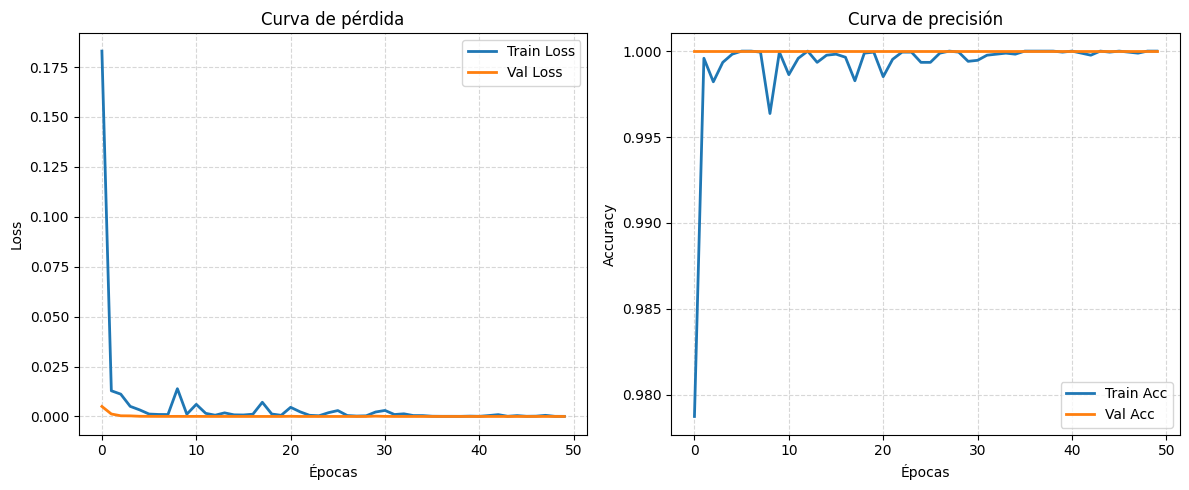

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Curva de pérdida
plt.subplot(1,2,1)
plt.plot(train_loss, label="Train Loss", linewidth=2)
plt.plot(test_loss, label="Val Loss", linewidth=2)
plt.title("Curva de pérdida")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

# Curva de precisión
plt.subplot(1,2,2)
plt.plot(train_acc, label="Train Acc", linewidth=2)
plt.plot(test_acc, label="Val Acc", linewidth=2)
plt.title("Curva de precisión")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


### Evaluación del modelo

Se realiza:
1. Inferencia sobre el conjunto de prueba.  
2. Cálculo de matriz de confusión.  
3. Reporte de clasificación completo.  
4. Visualización de confianza de las predicciones.


                  precision    recall  f1-score   support

     abrirPuerta       1.00      1.00      1.00      2000
 anteriorMelodia       1.00      1.00      1.00      1999
      modoNormal       1.00      1.00      1.00      2000
       modoSuper       1.00      1.00      1.00      2000
siguienteMelodia       1.00      1.00      1.00      2000

        accuracy                           1.00      9999
       macro avg       1.00      1.00      1.00      9999
    weighted avg       1.00      1.00      1.00      9999



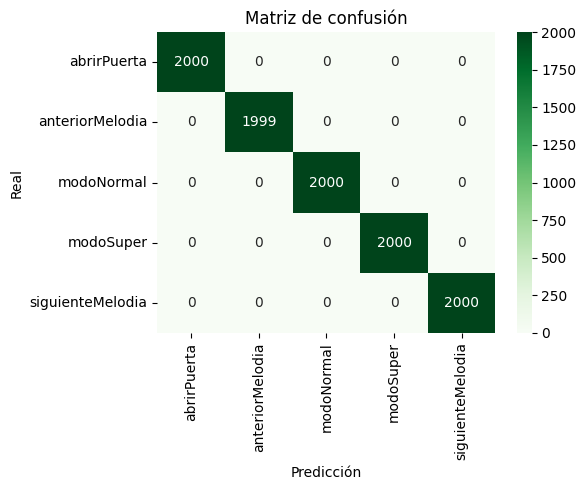

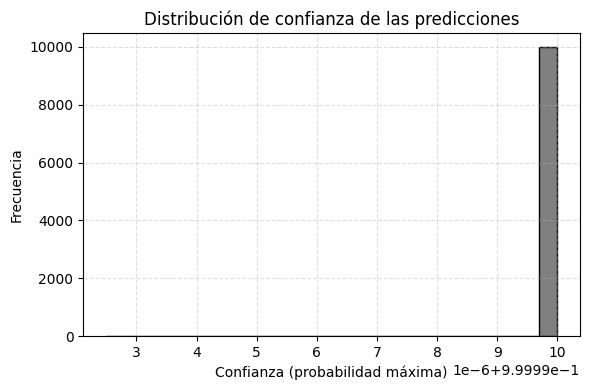

In [21]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.eval()
with torch.no_grad():
    logits = model(torch.tensor(X_test, dtype=torch.float32).to(DEVICE))
    probs = torch.softmax(logits, dim=1).cpu().numpy()
    preds = np.argmax(probs, axis=1)

# Reporte de métricas
print(classification_report(y_test, preds, target_names=encoder.classes_))

# Matriz de confusión
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()

# Distribución de confianza
plt.figure(figsize=(6,4))
plt.hist(np.max(probs, axis=1), bins=25, color="gray", edgecolor="black")
plt.xlabel("Confianza (probabilidad máxima)")
plt.ylabel("Frecuencia")
plt.title("Distribución de confianza de las predicciones")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


### Visualización combinada

Muestra simultáneamente la precisión y la pérdida a lo largo de las épocas.
Facilita observar equilibrio entre aprendizaje y estabilidad.


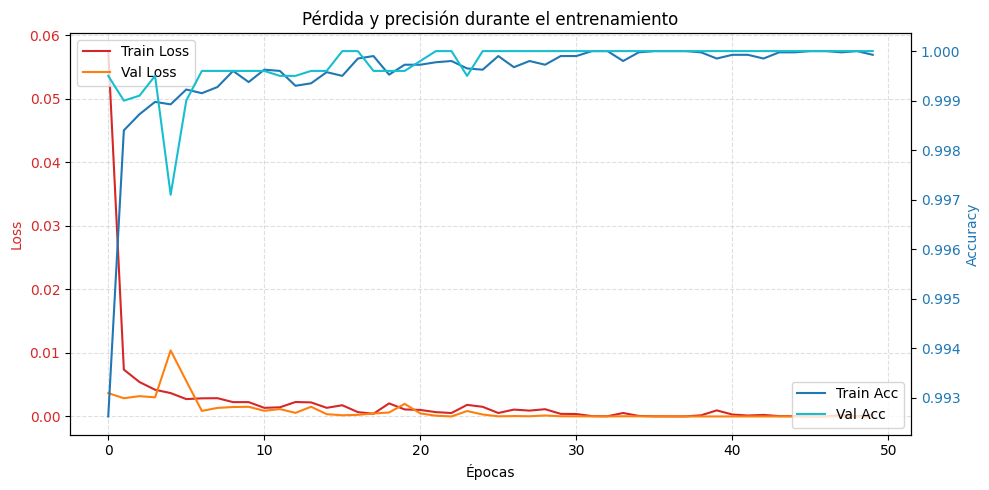

In [10]:
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(train_loss, color="tab:red", label="Train Loss")
ax1.plot(test_loss, color="tab:orange", label="Val Loss")
ax1.set_xlabel("Épocas")
ax1.set_ylabel("Loss", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")
ax1.legend(loc="upper left")
ax1.grid(True, linestyle="--", alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(train_acc, color="tab:blue", label="Train Acc")
ax2.plot(test_acc, color="tab:cyan", label="Val Acc")
ax2.set_ylabel("Accuracy", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")
ax2.legend(loc="lower right")

plt.title("Pérdida y precisión durante el entrenamiento")
plt.tight_layout()
plt.show()


### Guardado del modelo DGRNet

Guarda:
- Pesos entrenados (`.pt`)
- Codificador de etiquetas (`.npy`)
- Escalador de entrada (`.pkl`)  

Estos recursos permitirán la inferencia en tiempo real en el siguiente cuadernillo.


In [7]:
import joblib
os.makedirs("modelos", exist_ok=True)

torch.save(model.state_dict(), "modelos/dgrnet/dgrnet_gestos.pt")
np.save("modelos/dgrnet/label_encoder.npy", encoder.classes_)
joblib.dump(scaler, "modelos/dgrnet/scaler.pkl")

print("Modelo y objetos auxiliares guardados en /modelos/")
print("Archivos generados:")
print("- modelos/dgrnet/dgrnet_gestos.pt")
print("- modelos/dgrnet/label_encoder.npy")
print("- modelos/dgrnet/scaler.pkl")

Modelo y objetos auxiliares guardados en /modelos/
Archivos generados:
- modelos/dgrnet/dgrnet_gestos.pt
- modelos/dgrnet/label_encoder.npy
- modelos/dgrnet/scaler.pkl


### Verificación post-entrenamiento

Se carga el modelo guardado y se ejecuta una predicción de ejemplo
para asegurar que todo el pipeline funcione correctamente.


In [9]:
# Cargar modelo desde disco
model_loaded = DGRNet(num_features=X_train.shape[1],
                      num_classes=len(encoder.classes_)).to(DEVICE)
model_loaded.load_state_dict(torch.load("modelos/dgrnet/dgrnet_gestos.pt"))
model_loaded.eval()

# Predicción de muestra
sample = torch.tensor(X_test[:5], dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    pred = model_loaded(sample)
    probs = torch.softmax(pred, dim=1).cpu().numpy()
    classes_pred = encoder.inverse_transform(np.argmax(probs, axis=1))

print("Predicciones de prueba:", classes_pred)


Predicciones de prueba: ['abrirPuerta' 'anteriorMelodia' 'apagarLuces' 'modoSuper'
 'siguienteMelodia']


# Evaluación de desempeño en inferencia (modelo DGRNet)

En esta sección se carga el modelo entrenado y se simula una secuencia de predicciones.
Se comparan las etiquetas reales (`y_test`) con las predichas por el modelo.
Además, se muestran las probabilidades y la confianza promedio.


Usando dispositivo: cuda

Cargando modelo y objetos auxiliares...
Modelo cargado correctamente.

=== Resultados de Inferencia ===
Muestra 01 | Real: abrirPuerta          | Predicho: abrirPuerta          | Confianza: 100.00%
Muestra 02 | Real: anteriorMelodia      | Predicho: anteriorMelodia      | Confianza: 100.00%
Muestra 03 | Real: apagarLuces          | Predicho: apagarLuces          | Confianza: 100.00%
Muestra 04 | Real: siguienteMelodia     | Predicho: siguienteMelodia     | Confianza: 100.00%
Muestra 05 | Real: abrirPuerta          | Predicho: abrirPuerta          | Confianza: 100.00%
Muestra 06 | Real: modoNormal           | Predicho: modoNormal           | Confianza: 100.00%
Muestra 07 | Real: modoNormal           | Predicho: modoNormal           | Confianza: 100.00%
Muestra 08 | Real: modoSuper            | Predicho: modoSuper            | Confianza: 100.00%
Muestra 09 | Real: anteriorMelodia      | Predicho: anteriorMelodia      | Confianza: 100.00%
Muestra 10 | Real: sigui

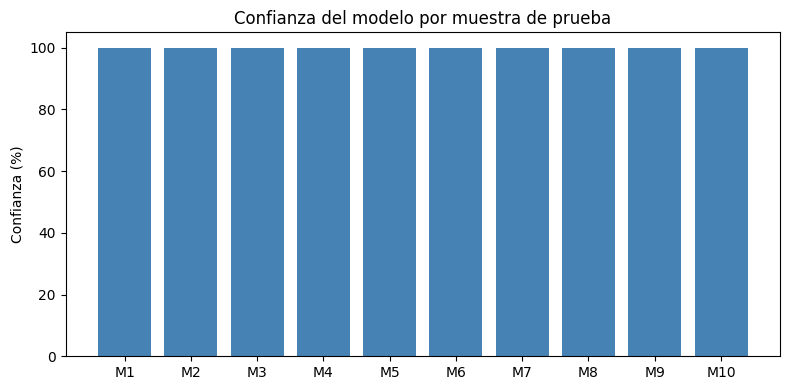

In [17]:
import torch
import torch.nn as nn
import numpy as np
import joblib
import pandas as pd
import glob
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Usando dispositivo:", DEVICE)

class DGRBlock(nn.Module):
    def __init__(self, in_f, out_f, dropout=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(in_f, out_f),
            nn.BatchNorm1d(out_f),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        return self.block(x)

class DGRNet(nn.Module):
    def __init__(self, num_features, num_classes):
        super().__init__()
        self.fc1 = DGRBlock(num_features, 512)
        self.fc2 = DGRBlock(512, 256)
        self.fc3 = DGRBlock(256, 128)
        self.res_proj = nn.Linear(256, 128)
        self.fc4 = DGRBlock(128, 64)
        self.output = nn.Linear(64, num_classes)
    def forward(self, x):
        x1 = self.fc1(x)
        x2 = self.fc2(x1)
        x3 = self.fc3(x2)
        x3 = x3 + self.res_proj(x2)
        x4 = self.fc4(x3)
        return self.output(x4)

model_dir = r"A:\GeneracionImagenes\TrabajoFinal\appMobileSynkrohogar\IAmultiModal\modelos\dgrnet"
dataset_dir = r"A:\GeneracionImagenes\TrabajoFinal\appMobileSynkrohogar\IAmultiModal\MegaDataSet"

print("\nCargando modelo y objetos auxiliares...")
MODEL_PATH = os.path.join(model_dir, "dgrnet_gestos.pt")
LABEL_PATH = os.path.join(model_dir, "label_encoder.npy")
SCALER_PATH = os.path.join(model_dir, "scaler.pkl")

labels = np.load(LABEL_PATH, allow_pickle=True)
encoder = LabelEncoder()
encoder.classes_ = labels
scaler = joblib.load(SCALER_PATH)

data, labels_y = [], []
for file in glob.glob(os.path.join(dataset_dir, "*.csv")):
    label = os.path.basename(file).replace(".csv", "")
    df = pd.read_csv(file, header=None)
    data.append(df.values)
    labels_y.extend([label]*len(df))

X = np.vstack(data)
y = encoder.transform(labels_y)
X_scaled = scaler.transform(X[:, :125])

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

state_dict = torch.load(MODEL_PATH, map_location=DEVICE)
num_features = 125
num_classes_pretrained = state_dict["output.weight"].shape[0]
model = DGRNet(num_features, num_classes_pretrained).to(DEVICE)
model.load_state_dict(state_dict, strict=False)
model.eval()
print("Modelo cargado correctamente.\n")

n_samples = min(10, len(X_test))
sample_tensor = torch.tensor(X_test[:n_samples], dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    logits = model(sample_tensor)
    probs = torch.softmax(logits, dim=1).cpu().numpy()
    preds = np.argmax(probs, axis=1)
    confs = np.max(probs, axis=1)

pred_names = encoder.inverse_transform(preds)
true_names = encoder.inverse_transform(y_test[:n_samples])

print("=== Resultados de Inferencia ===")
for i in range(n_samples):
    print(f"Muestra {i+1:02d} | Real: {true_names[i]:<20} | Predicho: {pred_names[i]:<20} | Confianza: {confs[i]*100:6.2f}%")

with torch.no_grad():
    logits_all = model(torch.tensor(X_test, dtype=torch.float32).to(DEVICE))
    y_pred_all = torch.argmax(logits_all, dim=1).cpu().numpy()

acc_total = np.mean(y_pred_all == y_test)
print(f"\nPrecisión total en inferencia: {acc_total*100:.2f}%")

plt.figure(figsize=(8,4))
plt.bar(range(n_samples), confs*100, color="steelblue")
plt.xticks(range(n_samples), [f"M{i+1}" for i in range(n_samples)])
plt.ylabel("Confianza (%)")
plt.title("Confianza del modelo por muestra de prueba")
plt.tight_layout()
plt.show()


In [11]:
import torch
import torch.nn as nn
import joblib
import numpy as np
import cv2
import mediapipe as mp
import os

# ===========================================================
# CONFIGURACION
# ===========================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BASE_DIR = r"A:\GeneracionImagenes\TrabajoFinal\appMobileSynkrohogar\IAmultiModal\MegaDataSet\modelos\dgrnet"

MODEL_PATH = os.path.join(BASE_DIR, "dgrnet_gestos.pt")
ENCODER_PATH = os.path.join(BASE_DIR, "label_encoder.npy")
SCALER_PATH = os.path.join(BASE_DIR, "scaler.pkl")

# ===========================================================
# CARGA DE MODELO
# ===========================================================
class DGRNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        return self.net(x)

# === Cargar label encoder y scaler ===
encoder = np.load(ENCODER_PATH, allow_pickle=True)
scaler = joblib.load(SCALER_PATH)

# Determinar dimensiones del modelo
input_dim = 63 * 2  # si usas solo x, y
# input_dim = 63 * 3  # si usas x, y, z (ajústalo según tu entrenamiento)
output_dim = len(encoder)

model = DGRNet(input_dim, output_dim).to(DEVICE)
state_dict = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(state_dict)
model.eval()

print(f"[OK] Modelo cargado: {MODEL_PATH}")
print(f"Clases detectadas: {encoder}")
print("=========================================\n")

# ===========================================================
# CAPTURA DE VIDEO
# ===========================================================
mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils

hands = mp_hands.Hands(max_num_hands=1, min_detection_confidence=0.7)

# Usa cámara local (0) o stream de ESP32
# cap = cv2.VideoCapture("http://192.168.191.128:81/stream")
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    raise RuntimeError("No se pudo acceder a la cámara")

print("[INFO] Cámara iniciada. Presiona 'q' para salir.")

# ===========================================================
# LOOP PRINCIPAL
# ===========================================================
while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    result = hands.process(rgb)

    if result.multi_hand_landmarks:
        for hand in result.multi_hand_landmarks:
            puntos = []
            for lm in hand.landmark:
                puntos.extend([lm.x, lm.y])  # usar x, y
                # puntos.extend([lm.x, lm.y, lm.z])  # si entrenaste con z

            if len(puntos) < input_dim:
                puntos += [0.0] * (input_dim - len(puntos))

            X = np.array(puntos).reshape(1, -1)
            X_scaled = scaler.transform(X)
            X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(DEVICE)

            with torch.no_grad():
                output = model(X_tensor)
                pred_idx = torch.argmax(output, dim=1).item()
                pred_label = encoder[pred_idx]

            mp_draw.draw_landmarks(frame, hand, mp_hands.HAND_CONNECTIONS)
            cv2.putText(frame, pred_label, (10, 40),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3)

    cv2.imshow("DGRNet Gestos - Inferencia", frame)
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()


ImportError: cannot import name 'runtime_version' from 'google.protobuf' (a:\GeneracionImagenes\efficientnet_env\lib\site-packages\google\protobuf\__init__.py)